# Sleep Disorder Diagnosis

I use the following dataset: https://www.kaggle.com/datasets/varishabatool/disorder

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## Clean Columns

In [3]:
df.columns = [c.strip().replace(' ', '_') for c in df.columns] 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person_ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep_Duration           374 non-null    float64
 5   Quality_of_Sleep         374 non-null    int64  
 6   Physical_Activity_Level  374 non-null    int64  
 7   Stress_Level             374 non-null    int64  
 8   BMI_Category             374 non-null    object 
 9   Blood_Pressure           374 non-null    object 
 10  Heart_Rate               374 non-null    int64  
 11  Daily_Steps              374 non-null    int64  
 12  Sleep_Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In this notebook, i only wanna focus on sleep disorder in general, not based on occupation

In [4]:
df.drop(columns = ['Person_ID'], axis = 1, inplace = True)
df.drop(columns = ['Occupation'], axis = 1, inplace = True)

## EDA

In [5]:
df.describe()

,Age,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,Heart_Rate,Daily_Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [6]:
df.isnull().sum()

Gender                       0
Age                          0
Sleep_Duration               0
Quality_of_Sleep             0
Physical_Activity_Level      0
Stress_Level                 0
BMI_Category                 0
Blood_Pressure               0
Heart_Rate                   0
Daily_Steps                  0
Sleep_Disorder             219
dtype: int64

## Handle Target Variable

In [7]:
df['Sleep_Disorder'].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

In [8]:
df['Sleep_Disorder'] = df['Sleep_Disorder'].fillna('None')

In [9]:
df['Sleep_Disorder'].value_counts(dropna=False).head()

Sleep_Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [10]:
df.isnull().sum()

Gender                     0
Age                        0
Sleep_Duration             0
Quality_of_Sleep           0
Physical_Activity_Level    0
Stress_Level               0
BMI_Category               0
Blood_Pressure             0
Heart_Rate                 0
Daily_Steps                0
Sleep_Disorder             0
dtype: int64

In [11]:
df['Sleep_Disorder'].unique()

array(['None', 'Sleep Apnea', 'Insomnia'], dtype=object)

Now, we resolve the problem with the NaN values, like the dataset says. Sleep Disorder Categories:

- None: No sleep disorder identified. (Fixed)
- Insomnia: Difficulty falling or staying asleep, resulting in poor sleep quality.
- Sleep Apnea: Breathing interruptions during sleep that may cause serious health risks.

## EDA

In [12]:
def plot_count_by_target(cat_col, figsize=(10,4)):
    ct = pd.crosstab(df[cat_col], df['Sleep_Disorder'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, figsize=figsize)
    plt.title(f'{cat_col} distribution across Sleep_Disorder (%)')
    plt.ylabel('Percent within category')
    plt.legend(title='Sleep_Disorder', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


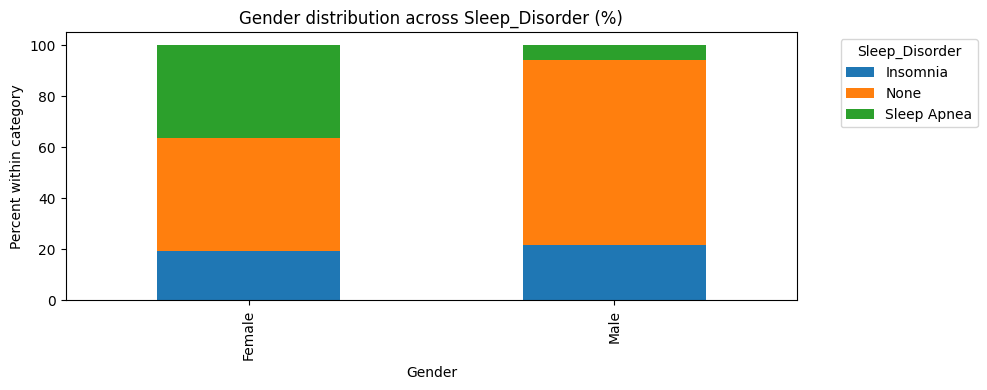

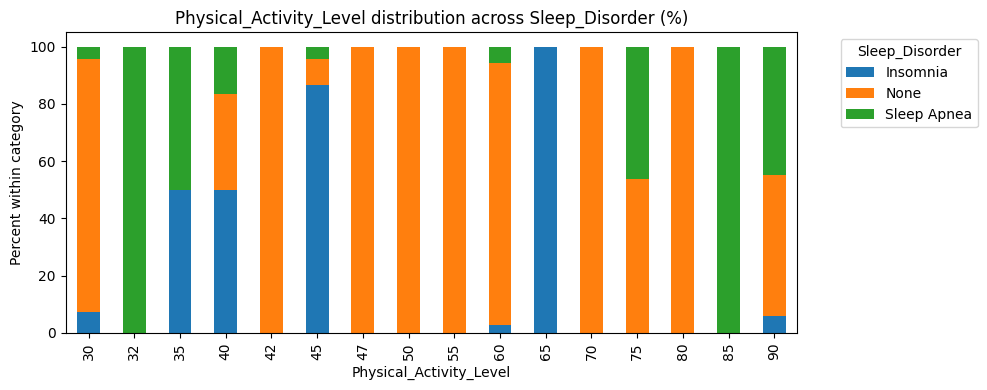

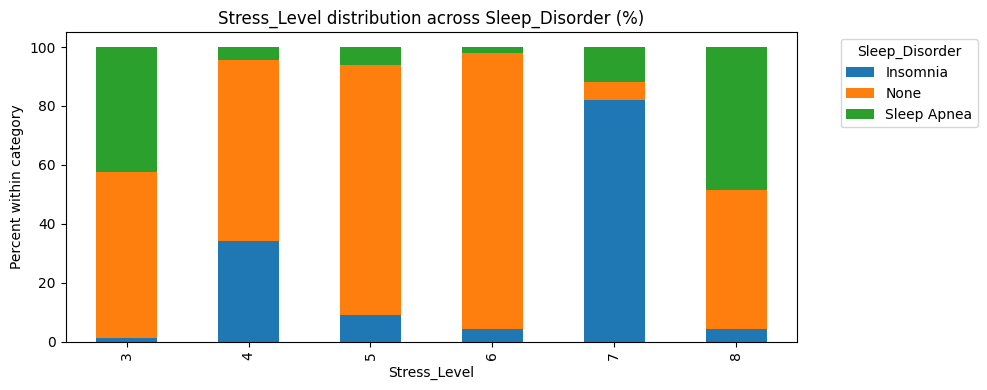

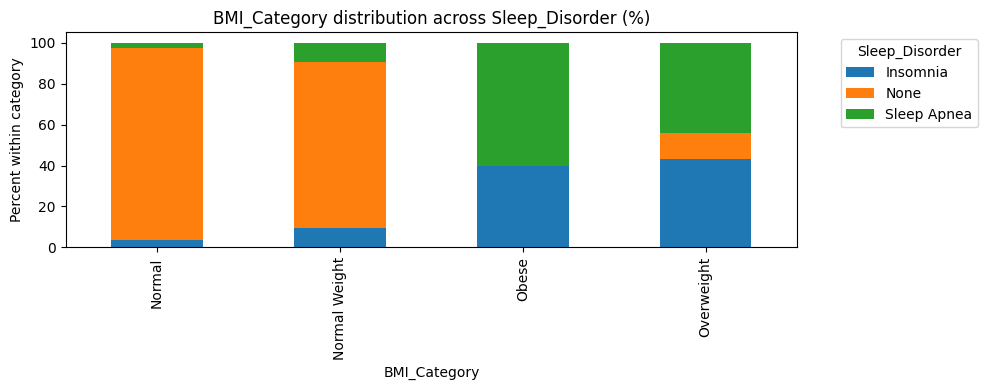

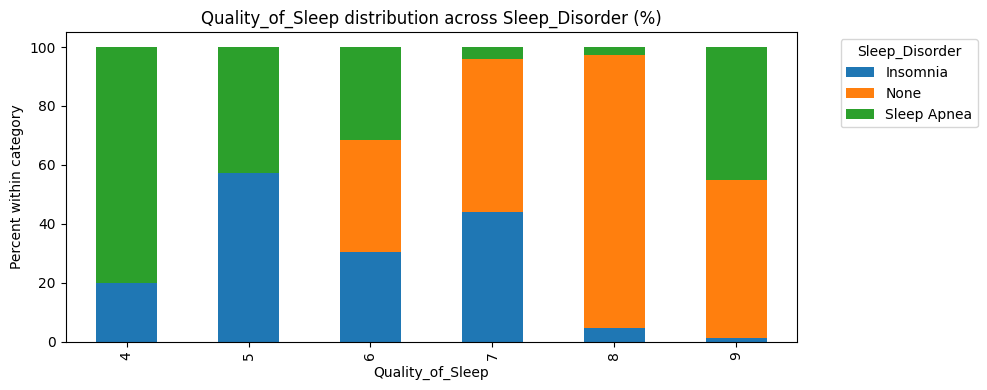

In [13]:
categorial_ft = ['Gender', 'Physical_Activity_Level', 'Stress_Level', 'BMI_Category', 'Quality_of_Sleep']
for c in categorial_ft:
    if c in df.columns:
        plot_count_by_target(c)

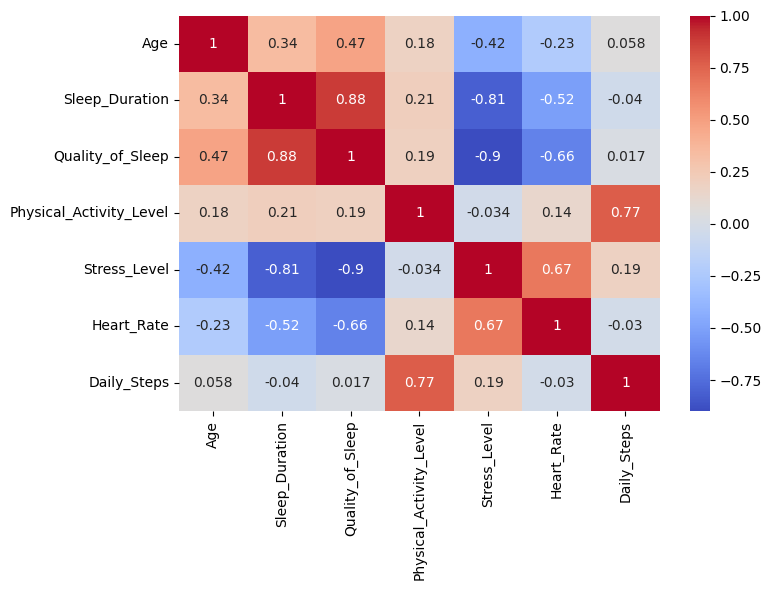

In [ ]:
num_df = df.select_dtypes(include = [np.number]).copy() #only numerical variables
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(num_df.corr(), cbar = True, annot = True, cmap = "coolwarm")
plt.tight_layout()
plt.show()

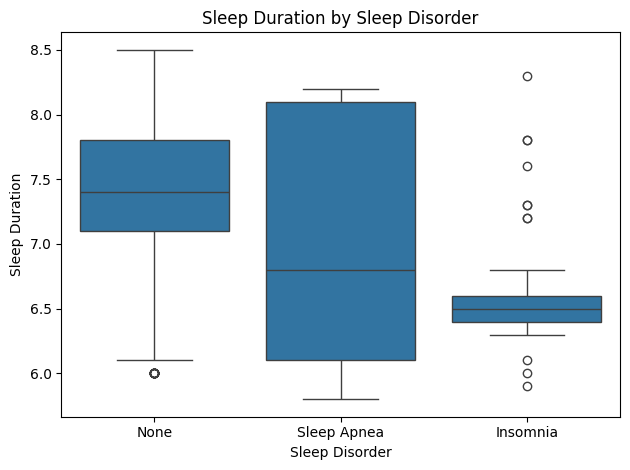

In [15]:
plt.figure()
sns.boxplot(x=df['Sleep_Disorder'], y=df['Sleep_Duration'])
plt.title('Sleep Duration by Sleep Disorder')
plt.ylabel("Sleep Duration")
plt.xlabel("Sleep Disorder")
plt.tight_layout()
plt.show()

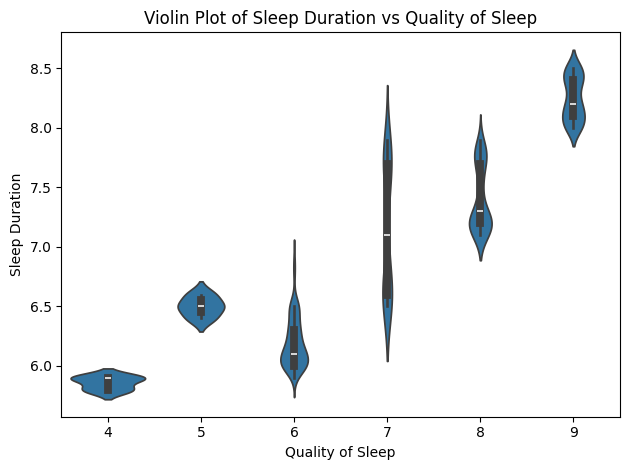

In [16]:
plt.figure()
sns.violinplot(x=df['Quality_of_Sleep'], y=df['Sleep_Duration'])
plt.title('Violin Plot of Sleep Duration vs Quality of Sleep')
plt.ylabel("Sleep Duration")
plt.xlabel("Quality of Sleep")
plt.tight_layout()
plt.show()

## Handle BMI

In [17]:
df['BMI_Category'].unique()

array(['Overweight', 'Normal', 'Obese', 'Normal Weight'], dtype=object)

In [18]:
df['BMI_Category'] = df['BMI_Category'].replace({
    'Normal Weight': 'Normal',  #unify
    'Overweight': 'Overweight',
    'Obese': 'Obese',
    'Normal': 'Normal'
})

df['BMI_Category'].unique()

array(['Overweight', 'Normal', 'Obese'], dtype=object)

## Blood Pressure

In [19]:
bp_split = df['Blood_Pressure'].astype(str).str.split('/', expand = True)
df['BP_Systolic'] = pd.to_numeric(bp_split[0])
df['BP_Diastolic'] = pd.to_numeric(bp_split[1])
df.drop(columns = ['Blood_Pressure'], inplace = True)
df.head()

,Gender,Age,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,BMI_Category,Heart_Rate,Daily_Steps,Sleep_Disorder,BP_Systolic,BP_Diastolic
0,Male,27,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


## Creating the One-Hot Encode

In [20]:
categorial_ft = ['Gender', 'BMI_Category', 'Sleep_Disorder']
categorial_ft

['Gender', 'BMI_Category', 'Sleep_Disorder']

In [ ]:
df_encoded = pd.get_dummies(df, columns = categorial_ft, drop_first = False)
print("Rows, columns:", df_encoded.shape)
df_encoded.head()

Rows, columns: (374, 12)


,Age,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,Heart_Rate,Daily_Steps,BP_Systolic,BP_Diastolic,Gender_Female,Gender_Male,BMI_Category_Normal,BMI_Category_Obese,BMI_Category_Overweight,Sleep_Disorder_Insomnia,Sleep_Disorder_None,Sleep_Disorder_Sleep Apnea
0,27,6.1,6,42,6,77,4200,126,83,False,True,False,False,True,False,True,False
1,28,6.2,6,60,8,75,10000,125,80,False,True,True,False,False,False,True,False
2,28,6.2,6,60,8,75,10000,125,80,False,True,True,False,False,False,True,False
3,28,5.9,4,30,8,85,3000,140,90,False,True,False,True,False,False,False,True
4,28,5.9,4,30,8,85,3000,140,90,False,True,False,True,False,False,False,True


In [22]:
bool_cols = df_encoded.select_dtypes(include=['bool']).columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [23]:
df_encoded.head()

,Age,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,Heart_Rate,Daily_Steps,BP_Systolic,BP_Diastolic,Gender_Female,Gender_Male,BMI_Category_Normal,BMI_Category_Obese,BMI_Category_Overweight,Sleep_Disorder_Insomnia,Sleep_Disorder_None,Sleep_Disorder_Sleep Apnea
0,27,6.1,6,42,6,77,4200,126,83,0,1,0,0,1,0,1,0
1,28,6.2,6,60,8,75,10000,125,80,0,1,1,0,0,0,1,0
2,28,6.2,6,60,8,75,10000,125,80,0,1,1,0,0,0,1,0
3,28,5.9,4,30,8,85,3000,140,90,0,1,0,1,0,0,0,1
4,28,5.9,4,30,8,85,3000,140,90,0,1,0,1,0,0,0,1


## Focused Correlation With Target

<Axes: >

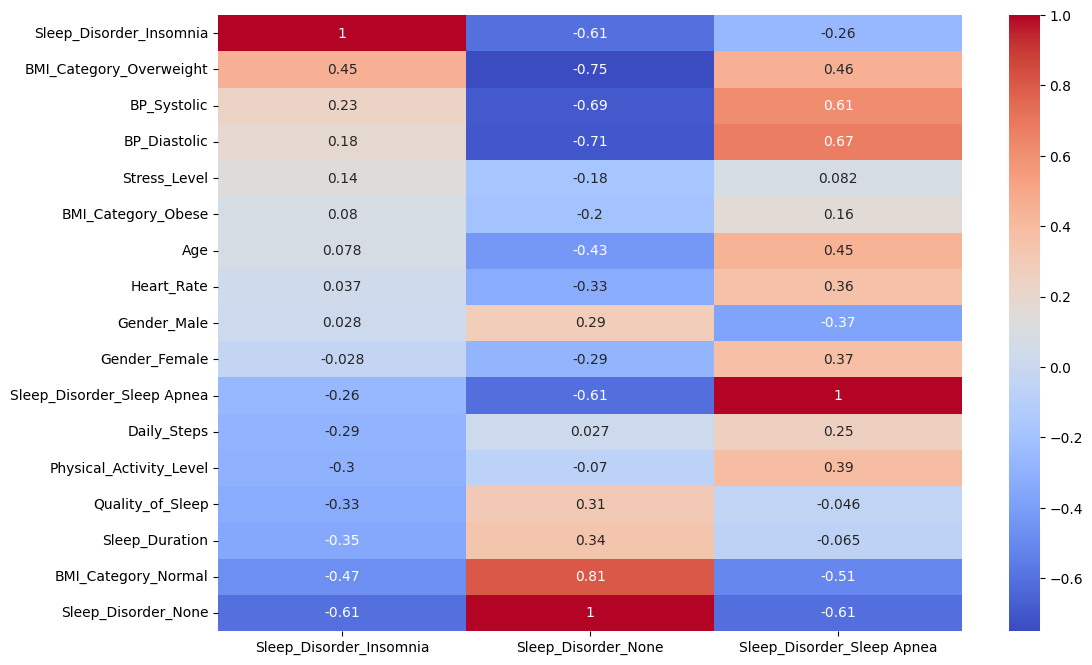

In [24]:
target_cols = ['Sleep_Disorder_Insomnia', 'Sleep_Disorder_None', 'Sleep_Disorder_Sleep Apnea']
corr_target = df_encoded.corr()[target_cols].sort_values(by=target_cols, ascending=False)

plt.figure(figsize = (12, 8))
sns.heatmap(corr_target, cbar = True, annot = True, cmap = "coolwarm")

### Interpretation Summary

- Sleep Duration and Stress Level are usually the strongest differentiators across disorder categories.
- Heart Rate and Blood Pressure tend to be higher for Sleep Apnea cases.
- Quality of Sleep and the Sleep Duration is lowest for Insomnia, matching clinical expectations.
- BMI often shifts toward *Overweight/Obese* for Sleep Apnea participants.
